## Выполнил Сарычев О.С. РИ-421001


##Данные


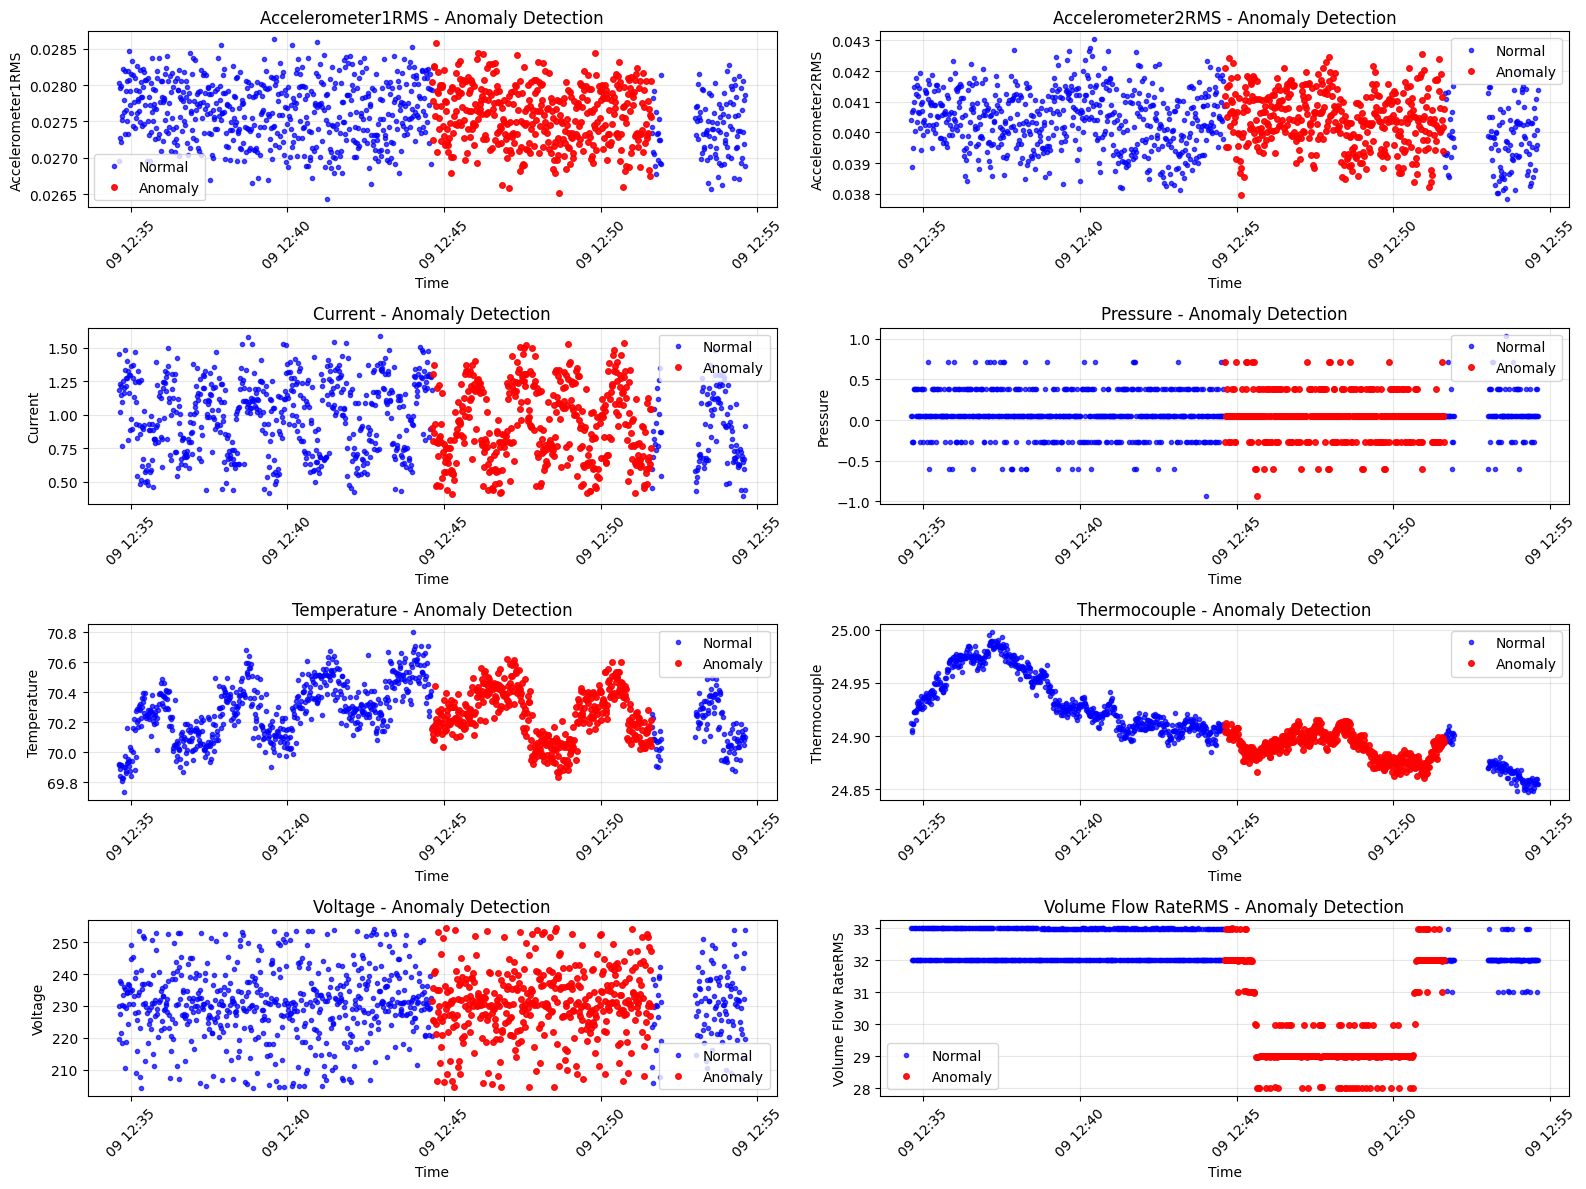

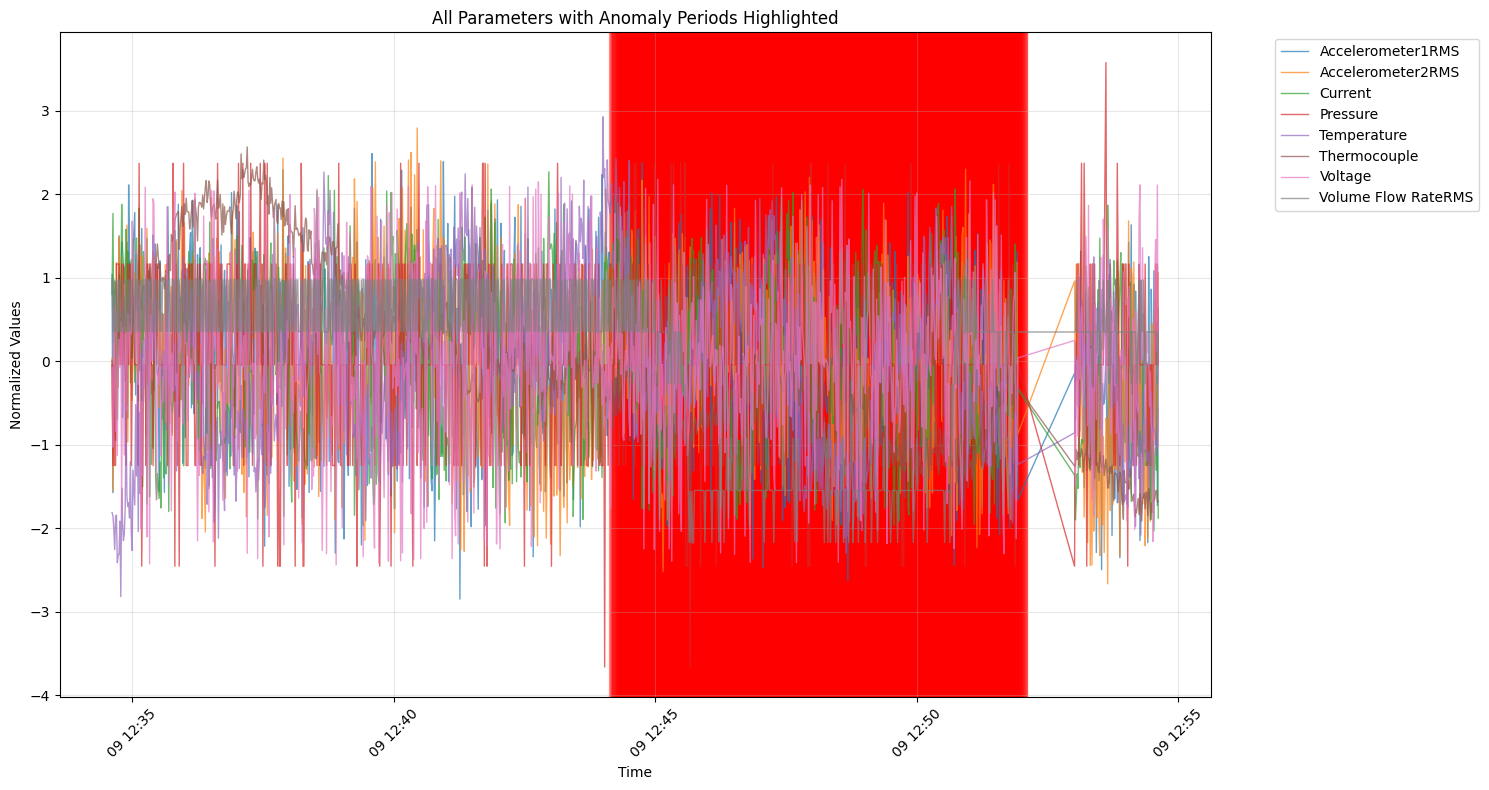

Статистика аномалий:
Всего записей: 1094
Аномальных записей: 405.0
Процент аномалий: 37.02%
Период с аномалиями: 2020-03-09 12:44:37 - 2020-03-09 12:51:37


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('skab_valve_1.csv', sep=';', parse_dates=['datetime'])

# Создание subplots для каждого параметра
parameters = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure',
              'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS']

fig, axes = plt.subplots(4, 2, figsize=(16, 12))
axes = axes.flatten()

# Цвета для нормальных и аномальных точек
colors = ['blue', 'red']
anomaly_labels = ['Normal', 'Anomaly']

for i, param in enumerate(parameters):
    if i < len(axes):
        # Разделение данных на нормальные и аномальные
        normal_data = df[df['anomaly'] == 0]
        anomaly_data = df[df['anomaly'] == 1]

        # Построение графика
        axes[i].plot(normal_data['datetime'], normal_data[param],
                    'o', color=colors[0], alpha=0.7, markersize=3, label=anomaly_labels[0])
        axes[i].plot(anomaly_data['datetime'], anomaly_data[param],
                    'o', color=colors[1], alpha=0.9, markersize=4, label=anomaly_labels[1])

        axes[i].set_title(f'{param} - Anomaly Detection')
        axes[i].set_xlabel('Time')
        axes[i].set_ylabel(param)
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

        # Поворот меток времени для лучшей читаемости
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Дополнительная визуализация - все параметры на одном графике (нормализованные)
fig, ax = plt.subplots(figsize=(15, 8))

# Нормализация данных для визуализации
normalized_df = df.copy()
for param in parameters:
    normalized_df[param] = (df[param] - df[param].mean()) / df[param].std()

# Построение всех параметров
for param in parameters:
    ax.plot(normalized_df['datetime'], normalized_df[param],
            label=param, alpha=0.7, linewidth=1)

# Выделение аномальных периодов
anomaly_periods = normalized_df[normalized_df['anomaly'] == 1]
for _, row in anomaly_periods.iterrows():
    ax.axvspan(row['datetime'] - pd.Timedelta(seconds=30),
               row['datetime'] + pd.Timedelta(seconds=30),
               color='red', alpha=0.3)

ax.set_title('All Parameters with Anomaly Periods Highlighted')
ax.set_xlabel('Time')
ax.set_ylabel('Normalized Values')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Статистика по аномалиям
print("Статистика аномалий:")
print(f"Всего записей: {len(df)}")
print(f"Аномальных записей: {df['anomaly'].sum()}")
print(f"Процент аномалий: {df['anomaly'].mean()*100:.2f}%")
print(f"Период с аномалиями: {df[df['anomaly'] == 1]['datetime'].min()} - {df[df['anomaly'] == 1]['datetime'].max()}")

##Поиск аномалий

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Фиксируем random state для воспроизводимости
np.random.seed(42)

# Загрузка данных
df = pd.read_csv('skab_valve_1.csv', sep=';', parse_dates=['datetime'])
print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())

# Определяем числовые колонки
numeric_columns = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure',
                   'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS']

Размер датасета: (1094, 11)

Первые 5 строк:
             datetime  Accelerometer1RMS  Accelerometer2RMS  Current  \
0 2020-03-09 12:34:37           0.028030           0.040400  1.18285   
1 2020-03-09 12:34:38           0.026952           0.038880  1.45268   
2 2020-03-09 12:34:39           0.027958           0.040660  1.02300   
3 2020-03-09 12:34:40           0.027277           0.040736  1.22751   
4 2020-03-09 12:34:41           0.027210           0.039489  1.21526   

   Pressure  Temperature  Thermocouple  Voltage  Volume Flow RateRMS  anomaly  \
0  0.054711      69.9219       24.9122  229.918              32.9875      0.0   
1 -0.273216      69.9147       24.9038  219.566              32.0129      0.0   
2  0.054711      69.8861       24.9055  237.717              32.9875      0.0   
3 -0.273216      69.8397       24.9110  227.621              32.0000      0.0   
4 -0.273216      69.9136       24.9110  221.634              32.0129      0.0   

   changepoint  
0          0.0  
1

##1. Статистические эвристики

In [11]:
#  Реализация метода квартилей для обнаружения аномалий
def detect_anomalies_quartile_method(df, columns, multiplier=1.5):
    """
    Обнаружение аномалий с помощью метода квартилей
    Q1 - первый квартиль (25-й процентиль)
    Q3 - третий квартиль (75-й процентиль)
    """
    df_anomaly = df.copy()

    for col in columns:
        # Вычисляем квартили
        Q1 = df[col].quantile(0.25)  # 25-й процентиль
        Q3 = df[col].quantile(0.75)  # 75-й процентиль
        IQR = Q3 - Q1  # Межквартильный размах

        # Вычисляем границы для аномалий
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR

        # Отмечаем аномалии (значения за пределами границ)
        df_anomaly[f'{col}_anomaly'] = ((df[col] < lower_bound) | (df[col] > upper_bound)).astype(int)

    # Суммируем аномалии по всем колонкам
    anomaly_cols = [f'{col}_anomaly' for col in columns]
    df_anomaly['quartile_anomaly'] = df_anomaly[anomaly_cols].sum(axis=1)
    df_anomaly['quartile_anomaly_binary'] = (df_anomaly['quartile_anomaly'] > 0).astype(int)

    return df_anomaly

# Применяем метод квартилей с разными множителями
df_quartile_15 = detect_anomalies_quartile_method(df, numeric_columns, multiplier=1.5)
df_quartile_30 = detect_anomalies_quartile_method(df, numeric_columns, multiplier=3.0)

print("Статистика метода квартилей:")
print(f"Метод 1.5: {df_quartile_15['quartile_anomaly_binary'].sum()} аномалий ({df_quartile_15['quartile_anomaly_binary'].mean()*100:.2f}%)")
print(f"Метод 3.0: {df_quartile_30['quartile_anomaly_binary'].sum()} аномалий ({df_quartile_30['quartile_anomaly_binary'].mean()*100:.2f}%)")

Статистика метода квартилей:
Метод 1.5: 105 аномалий (9.60%)
Метод 3.0: 2 аномалий (0.18%)


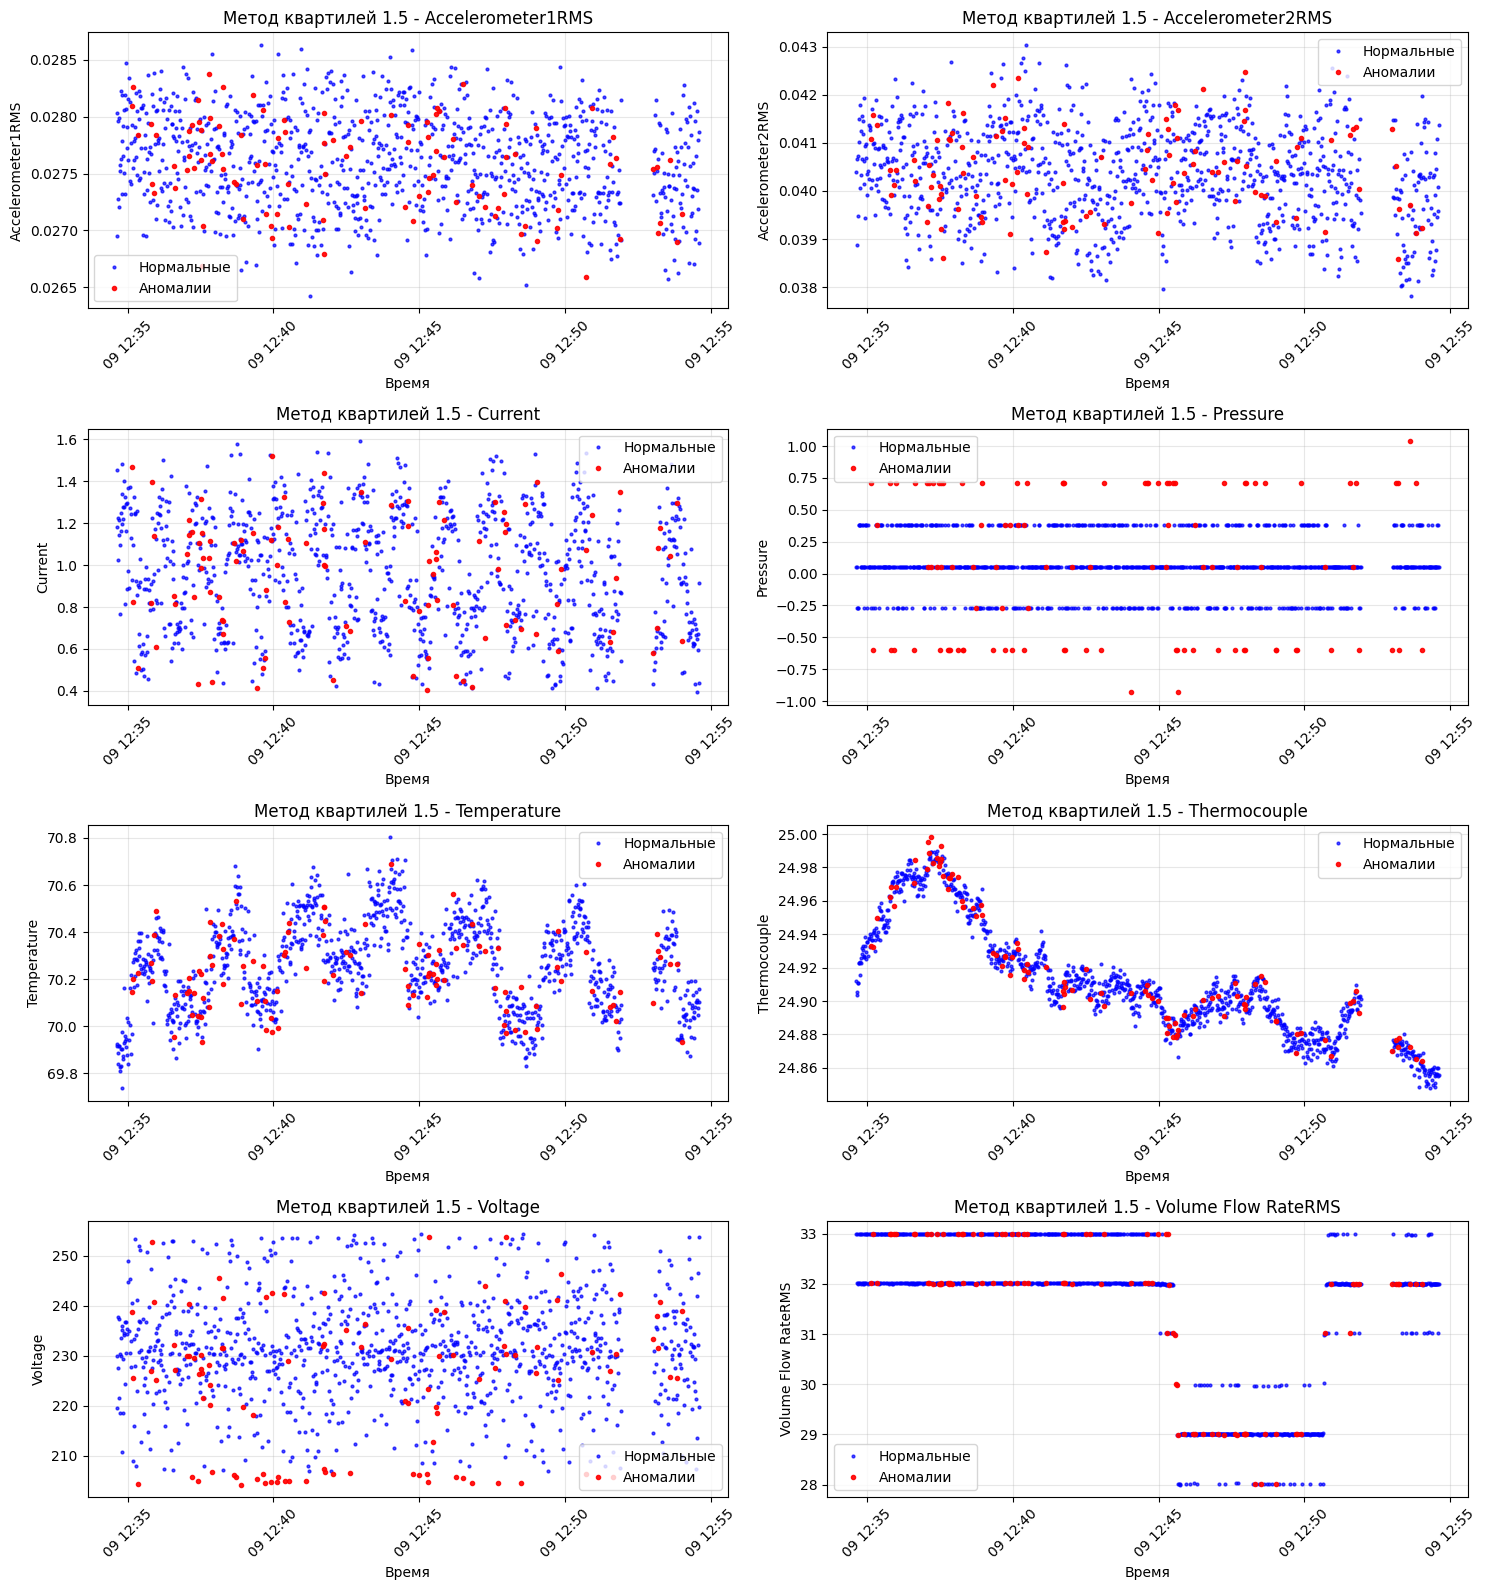

In [13]:
#  Визуализация результатов метода квартилей
fig, axes = plt.subplots(4, 2, figsize=(15, 16))

# Визуализация для метода с множителем 1.5
for i, col in enumerate(numeric_columns):
    row = i // 2
    col_idx = i % 2
    ax = axes[row, col_idx]

    normal_data = df_quartile_15[df_quartile_15['quartile_anomaly_binary'] == 0]
    anomaly_data = df_quartile_15[df_quartile_15['quartile_anomaly_binary'] == 1]

    ax.plot(normal_data['datetime'], normal_data[col], 'o',
            color='blue', alpha=0.7, markersize=2, label='Нормальные')
    ax.plot(anomaly_data['datetime'], anomaly_data[col], 'o',
            color='red', alpha=0.9, markersize=3, label='Аномалии')

    ax.set_title(f'Метод квартилей 1.5 - {col}')
    ax.set_xlabel('Время')
    ax.set_ylabel(col)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Метод квартилей 1.5 Метрики:
Точность: 0.5996
Precision: 0.3429
Recall: 0.0889
F1-Score: 0.1412

Метод квартилей 3.0 Метрики:
Точность: 0.6298
Precision: 0.5000
Recall: 0.0025
F1-Score: 0.0049


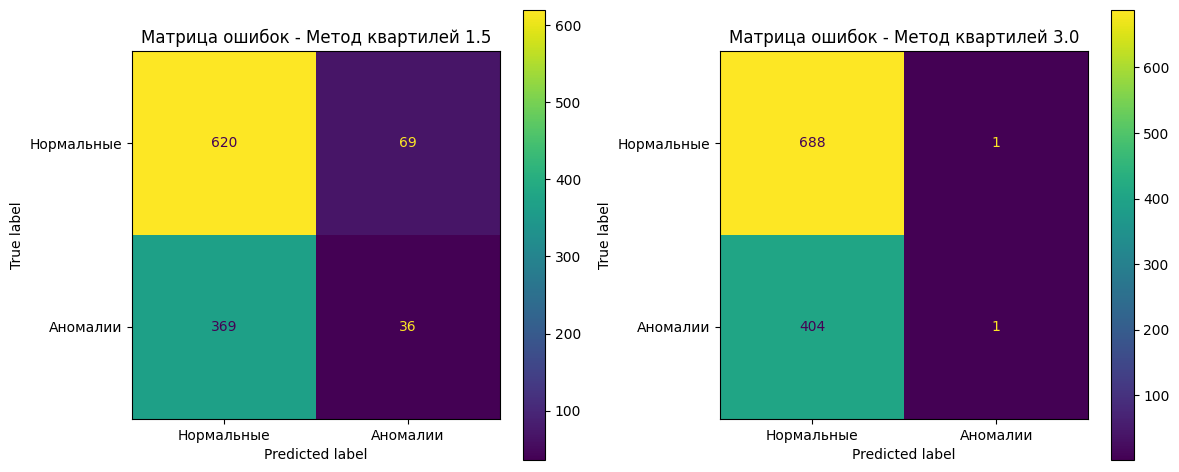

In [14]:
#  Оценка качества метода квартилей
def evaluate_model(y_true, y_pred, model_name):
    """Оценка качества модели"""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\n{model_name} Метрики:")
    print(f"Точность: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    return cm, {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Оценка методов квартилей
cm_quartile_15, metrics_quartile_15 = evaluate_model(df['anomaly'], df_quartile_15['quartile_anomaly_binary'], "Метод квартилей 1.5")
cm_quartile_30, metrics_quartile_30 = evaluate_model(df['anomaly'], df_quartile_30['quartile_anomaly_binary'], "Метод квартилей 3.0")

# Визуализация матрицы ошибок
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_quartile_15, display_labels=['Нормальные', 'Аномалии']).plot(ax=ax1)
ax1.set_title('Матрица ошибок - Метод квартилей 1.5')

ConfusionMatrixDisplay(cm_quartile_30, display_labels=['Нормальные', 'Аномалии']).plot(ax=ax2)
ax2.set_title('Матрица ошибок - Метод квартилей 3.0')

plt.tight_layout()
plt.show()

##2. Кластеризация

In [15]:
#  Создание дополнительных признаков
def create_features(df, numeric_columns):
    """Создание дополнительных признаков для улучшения качества моделей"""
    df_fe = df.copy()

    # Признаки времени
    df_fe['hour'] = df_fe['datetime'].dt.hour
    df_fe['minute'] = df_fe['datetime'].dt.minute
    df_fe['second'] = df_fe['datetime'].dt.second
    df_fe['time_of_day'] = df_fe['datetime'].dt.hour + df_fe['datetime'].dt.minute / 60

    # Лаги для основных параметров (значения в предыдущие моменты времени)
    for col in numeric_columns:
        df_fe[f'{col}_lag1'] = df_fe[col].shift(1)
        df_fe[f'{col}_lag2'] = df_fe[col].shift(2)
        df_fe[f'{col}_lag3'] = df_fe[col].shift(3)

    # Скользящие статистики (подвижные средние и стандартные отклонения)
    window_size = 5
    for col in numeric_columns:
        df_fe[f'{col}_rolling_mean'] = df_fe[col].rolling(window=window_size, min_periods=1).mean()
        df_fe[f'{col}_rolling_std'] = df_fe[col].rolling(window=window_size, min_periods=1).std()
        df_fe[f'{col}_rolling_range'] = (df_fe[col].rolling(window=window_size, min_periods=1).max() -
                                        df_fe[col].rolling(window=window_size, min_periods=1).min())

    # Производные (разности между последовательными значениями)
    for col in numeric_columns:
        df_fe[f'{col}_diff1'] = df_fe[col].diff(1)
        df_fe[f'{col}_diff2'] = df_fe[col].diff(2)

    # Взаимодействия признаков (комбинации разных параметров)
    df_fe['accel_product'] = df_fe['Accelerometer1RMS'] * df_fe['Accelerometer2RMS']
    df_fe['current_pressure_ratio'] = df_fe['Current'] / (df_fe['Pressure'] + 1e-6)
    df_fe['temp_thermo_diff'] = df_fe['Temperature'] - df_fe['Thermocouple']

    # Заполнение пропущенных значений
    df_fe = df_fe.fillna(method='bfill').fillna(method='ffill')

    return df_fe

# Создание признаков
df_fe = create_features(df, numeric_columns)
print(f"Размер датасета после создания признаков: {df_fe.shape}")
print(f"Количество признаков: {len(df_fe.columns)}")

Размер датасета после создания признаков: (1094, 82)
Количество признаков: 82


In [17]:
# Подготовка данных для кластеризации
# Выбираем только числовые признаки для кластеризации
feature_columns = [col for col in df_fe.columns if col not in ['datetime', 'anomaly', 'changepoint']
                   and df_fe[col].dtype in ['float64', 'int64']]

print(f"Используется {len(feature_columns)} признаков для кластеризации")

# Масштабирование данных (приведение к одинаковому масштабу)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_fe[feature_columns])

#  Кластеризация K-means
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Предполагаем, что меньший кластер - аномалии
cluster_sizes = np.bincount(kmeans_labels)
anomaly_cluster = np.argmin(cluster_sizes)
df_fe['kmeans_anomaly'] = (kmeans_labels == anomaly_cluster).astype(int)

#  Кластеризация DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)
df_fe['dbscan_anomaly'] = (dbscan_labels == -1).astype(int)

print("\nРезультаты кластеризации:")
print(f"K-means аномалий: {df_fe['kmeans_anomaly'].sum()} ({df_fe['kmeans_anomaly'].mean()*100:.2f}%)")
print(f"DBSCAN аномалий: {df_fe['dbscan_anomaly'].sum()} ({df_fe['dbscan_anomaly'].mean()*100:.2f}%)")

Используется 78 признаков для кластеризации

Результаты кластеризации:
K-means аномалий: 489 (44.70%)
DBSCAN аномалий: 1094 (100.00%)


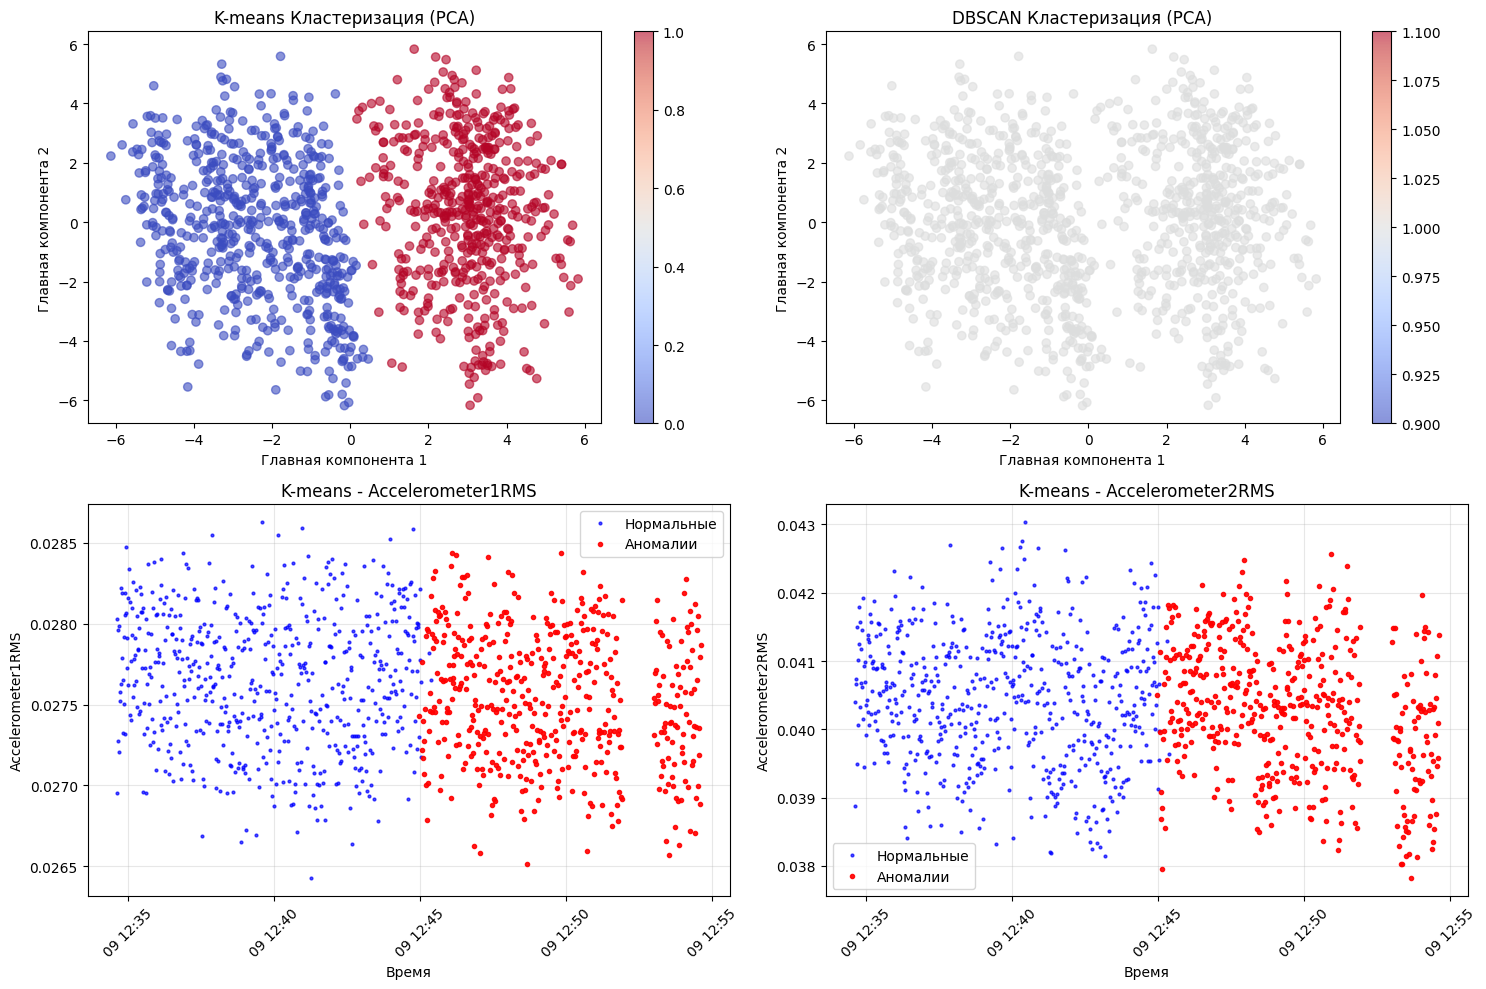

In [18]:
# Визуализация результатов кластеризации
# PCA для визуализации в 2D (упрощение многомерных данных)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# K-means визуализация
scatter1 = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=df_fe['kmeans_anomaly'],
                             cmap='coolwarm', alpha=0.6)
axes[0, 0].set_title('K-means Кластеризация (PCA)')
axes[0, 0].set_xlabel('Главная компонента 1')
axes[0, 0].set_ylabel('Главная компонента 2')
plt.colorbar(scatter1, ax=axes[0, 0])

# DBSCAN визуализация
scatter2 = axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=df_fe['dbscan_anomaly'],
                             cmap='coolwarm', alpha=0.6)
axes[0, 1].set_title('DBSCAN Кластеризация (PCA)')
axes[0, 1].set_xlabel('Главная компонента 1')
axes[0, 1].set_ylabel('Главная компонента 2')
plt.colorbar(scatter2, ax=axes[0, 1])

# Временные ряды для K-means
for i, col in enumerate(numeric_columns[:2]):
    ax = axes[1, i]
    normal_data = df_fe[df_fe['kmeans_anomaly'] == 0]
    anomaly_data = df_fe[df_fe['kmeans_anomaly'] == 1]

    ax.plot(normal_data['datetime'], normal_data[col], 'o',
            color='blue', alpha=0.7, markersize=2, label='Нормальные')
    ax.plot(anomaly_data['datetime'], anomaly_data[col], 'o',
            color='red', alpha=0.9, markersize=3, label='Аномалии')

    ax.set_title(f'K-means - {col}')
    ax.set_xlabel('Время')
    ax.set_ylabel(col)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


K-means Метрики:
Точность: 0.8739
Precision: 0.7730
Recall: 0.9333
F1-Score: 0.8456

DBSCAN Метрики:
Точность: 0.3702
Precision: 0.3702
Recall: 1.0000
F1-Score: 0.5404


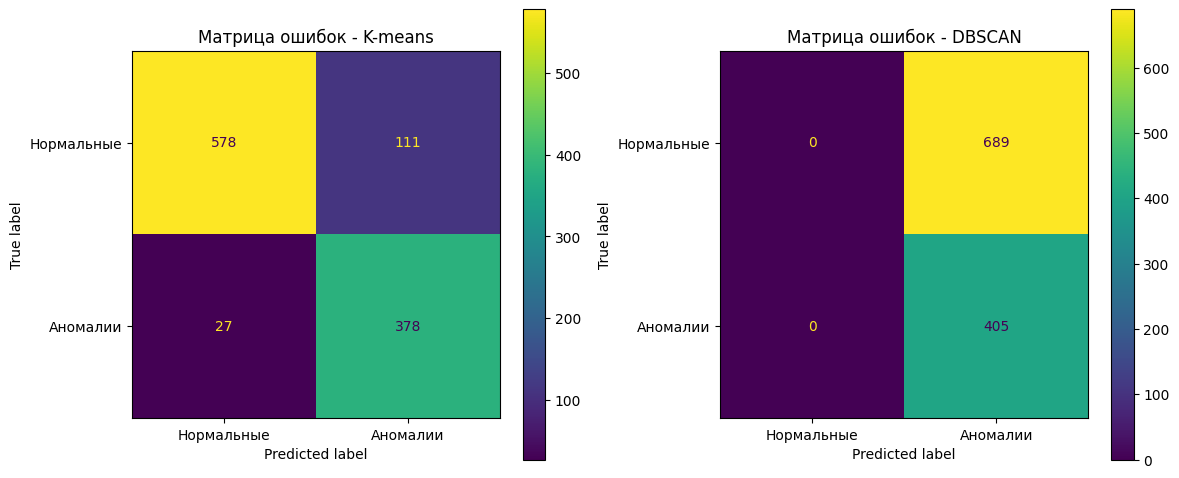

In [19]:
#  Оценка качества кластеризации
cm_kmeans, metrics_kmeans = evaluate_model(df_fe['anomaly'], df_fe['kmeans_anomaly'], "K-means")
cm_dbscan, metrics_dbscan = evaluate_model(df_fe['anomaly'], df_fe['dbscan_anomaly'], "DBSCAN")

# Визуализация матрицы ошибок
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_kmeans, display_labels=['Нормальные', 'Аномалии']).plot(ax=ax1)
ax1.set_title('Матрица ошибок - K-means')

ConfusionMatrixDisplay(cm_dbscan, display_labels=['Нормальные', 'Аномалии']).plot(ax=ax2)
ax2.set_title('Матрица ошибок - DBSCAN')

plt.tight_layout()
plt.show()

##3. Isolation Forest

Isolation Forest аномалий: 110 (10.05%)


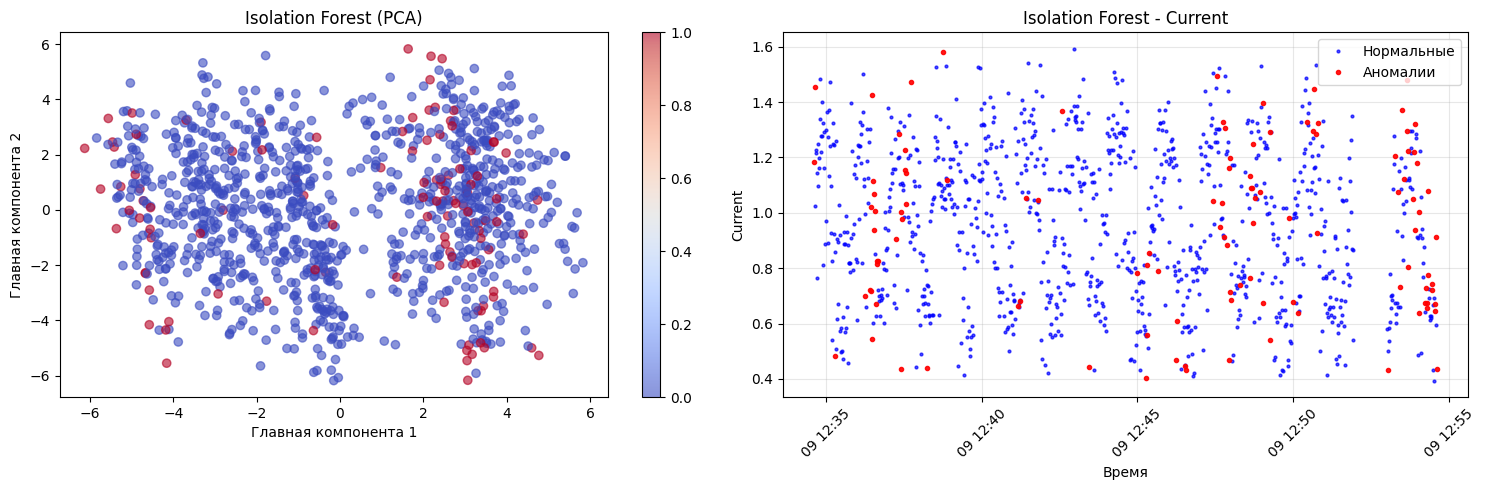

In [20]:
#  Isolation Forest - алгоритм, специально разработанный для обнаружения аномалий
iso_forest = IsolationForest(contamination=0.1, random_state=42, n_estimators=100)
iso_predictions = iso_forest.fit_predict(X_scaled)
df_fe['isolation_anomaly'] = (iso_predictions == -1).astype(int)

print(f"Isolation Forest аномалий: {df_fe['isolation_anomaly'].sum()} ({df_fe['isolation_anomaly'].mean()*100:.2f}%)")

#  Визуализация Isolation Forest
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# PCA визуализация
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df_fe['isolation_anomaly'],
                         cmap='coolwarm', alpha=0.6)
axes[0].set_title('Isolation Forest (PCA)')
axes[0].set_xlabel('Главная компонента 1')
axes[0].set_ylabel('Главная компонента 2')
plt.colorbar(scatter, ax=axes[0])

# Временные ряды
ax = axes[1]
col = 'Current'  # Пример одного параметра
normal_data = df_fe[df_fe['isolation_anomaly'] == 0]
anomaly_data = df_fe[df_fe['isolation_anomaly'] == 1]

ax.plot(normal_data['datetime'], normal_data[col], 'o',
        color='blue', alpha=0.7, markersize=2, label='Нормальные')
ax.plot(anomaly_data['datetime'], anomaly_data[col], 'o',
        color='red', alpha=0.9, markersize=3, label='Аномалии')

ax.set_title(f'Isolation Forest - {col}')
ax.set_xlabel('Время')
ax.set_ylabel(col)
ax.legend()
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Isolation Forest Метрики:
Точность: 0.6115
Precision: 0.4091
Recall: 0.1111
F1-Score: 0.1748


<Figure size 600x500 with 0 Axes>

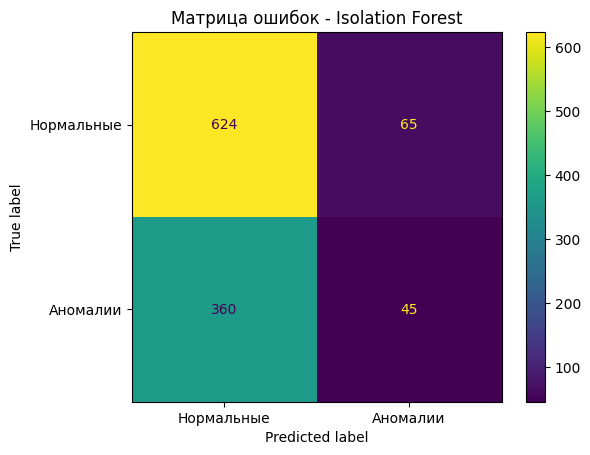

In [21]:
# Оценка качества Isolation Forest
cm_iso, metrics_iso = evaluate_model(df_fe['anomaly'], df_fe['isolation_anomaly'], "Isolation Forest")

# Визуализация матрицы ошибок
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm_iso, display_labels=['Нормальные', 'Аномалии']).plot()
plt.title('Матрица ошибок - Isolation Forest')
plt.show()

##4. Сравнение всех методов

Сравнение всех методов:
                     accuracy  precision  recall      f1
Метод квартилей 1.5    0.5996     0.3429  0.0889  0.1412
Метод квартилей 3.0    0.6298     0.5000  0.0025  0.0049
K-means                0.8739     0.7730  0.9333  0.8456
DBSCAN                 0.3702     0.3702  1.0000  0.5404
Isolation Forest       0.6115     0.4091  0.1111  0.1748


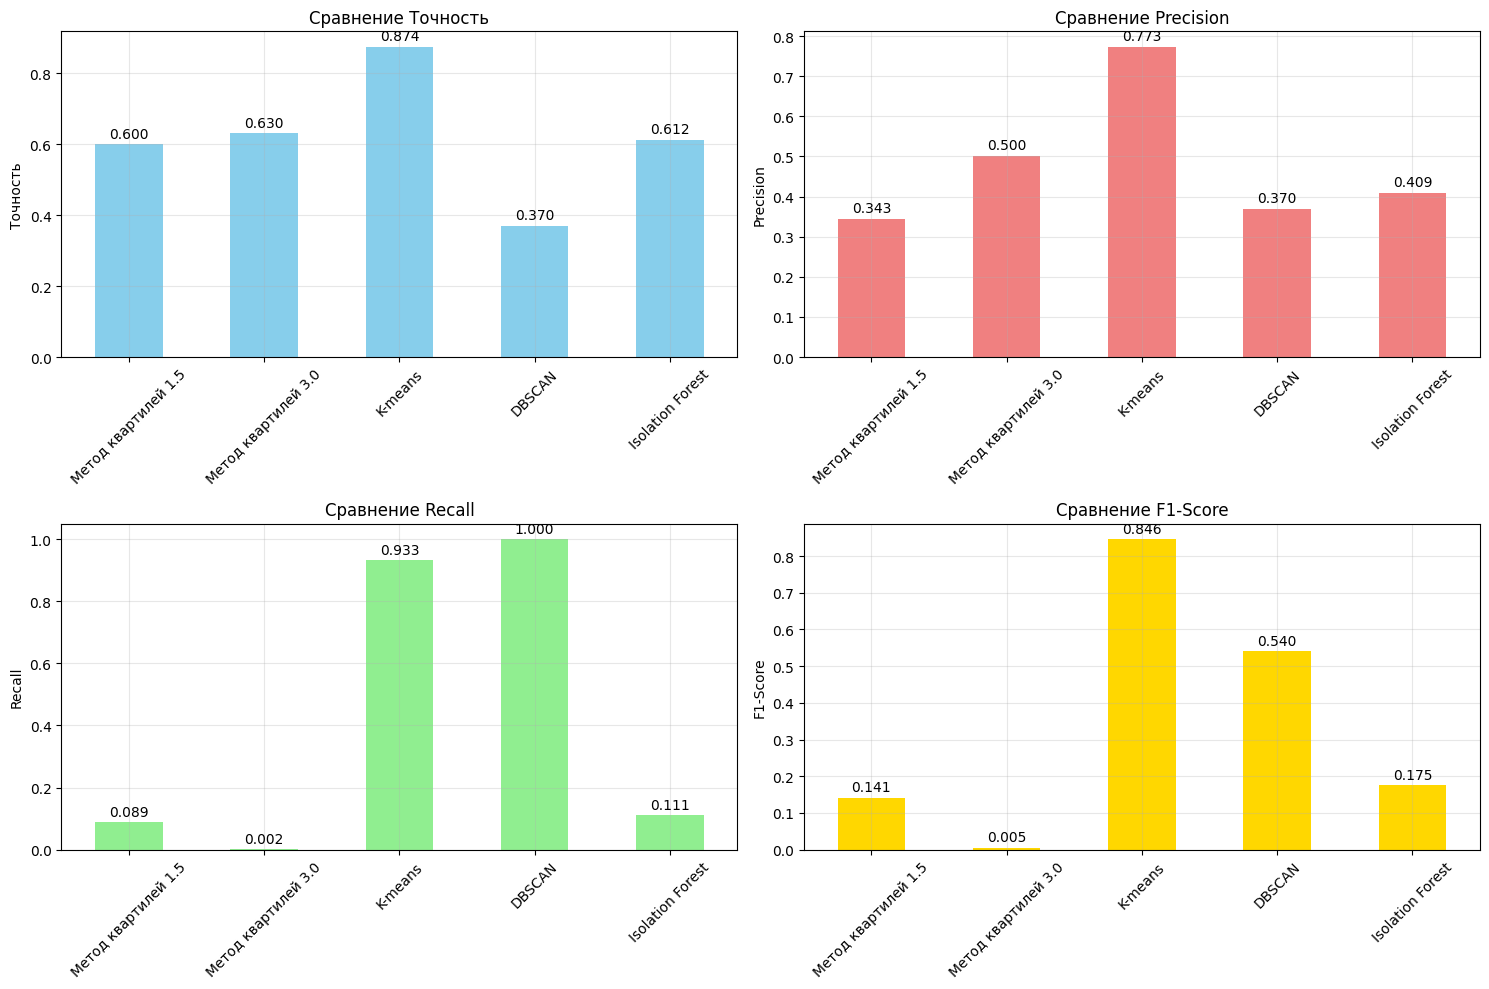


Сводная таблица результатов:
                 Метод  Обнаружено аномалий  Процент аномалий  F1-Оценка
0  Метод квартилей 1.5                  105            9.5978     0.1412
1  Метод квартилей 3.0                    2            0.1828     0.0049
2              K-means                  489           44.6984     0.8456
3               DBSCAN                 1094          100.0000     0.5404
4     Isolation Forest                  110           10.0548     0.1748


In [22]:
# Агрегация результатов
results_comparison = pd.DataFrame({
    'Метод квартилей 1.5': metrics_quartile_15,
    'Метод квартилей 3.0': metrics_quartile_30,
    'K-means': metrics_kmeans,
    'DBSCAN': metrics_dbscan,
    'Isolation Forest': metrics_iso
}).T

print("Сравнение всех методов:")
print(results_comparison.round(4))

#  Визуализация сравнения
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Метрики сравнения
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']
metric_names = ['Точность', 'Precision', 'Recall', 'F1-Score']

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i//2, i%2]
    results_comparison[metric].plot(kind='bar', ax=ax, color=colors[i])
    ax.set_title(f'Сравнение {metric_names[i]}')
    ax.set_ylabel(metric_names[i])
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

    # Добавляем значения на столбцы
    for j, v in enumerate(results_comparison[metric]):
        ax.text(j, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

#  Сводная таблица
summary_table = pd.DataFrame({
    'Метод': ['Метод квартилей 1.5', 'Метод квартилей 3.0', 'K-means', 'DBSCAN', 'Isolation Forest'],
    'Обнаружено аномалий': [
        df_quartile_15['quartile_anomaly_binary'].sum(),
        df_quartile_30['quartile_anomaly_binary'].sum(),
        df_fe['kmeans_anomaly'].sum(),
        df_fe['dbscan_anomaly'].sum(),
        df_fe['isolation_anomaly'].sum()
    ],
    'Процент аномалий': [
        df_quartile_15['quartile_anomaly_binary'].mean() * 100,
        df_quartile_30['quartile_anomaly_binary'].mean() * 100,
        df_fe['kmeans_anomaly'].mean() * 100,
        df_fe['dbscan_anomaly'].mean() * 100,
        df_fe['isolation_anomaly'].mean() * 100
    ],
    'F1-Оценка': [
        metrics_quartile_15['f1'],
        metrics_quartile_30['f1'],
        metrics_kmeans['f1'],
        metrics_dbscan['f1'],
        metrics_iso['f1']
    ]
})

print("\nСводная таблица результатов:")
print(summary_table.round(4))

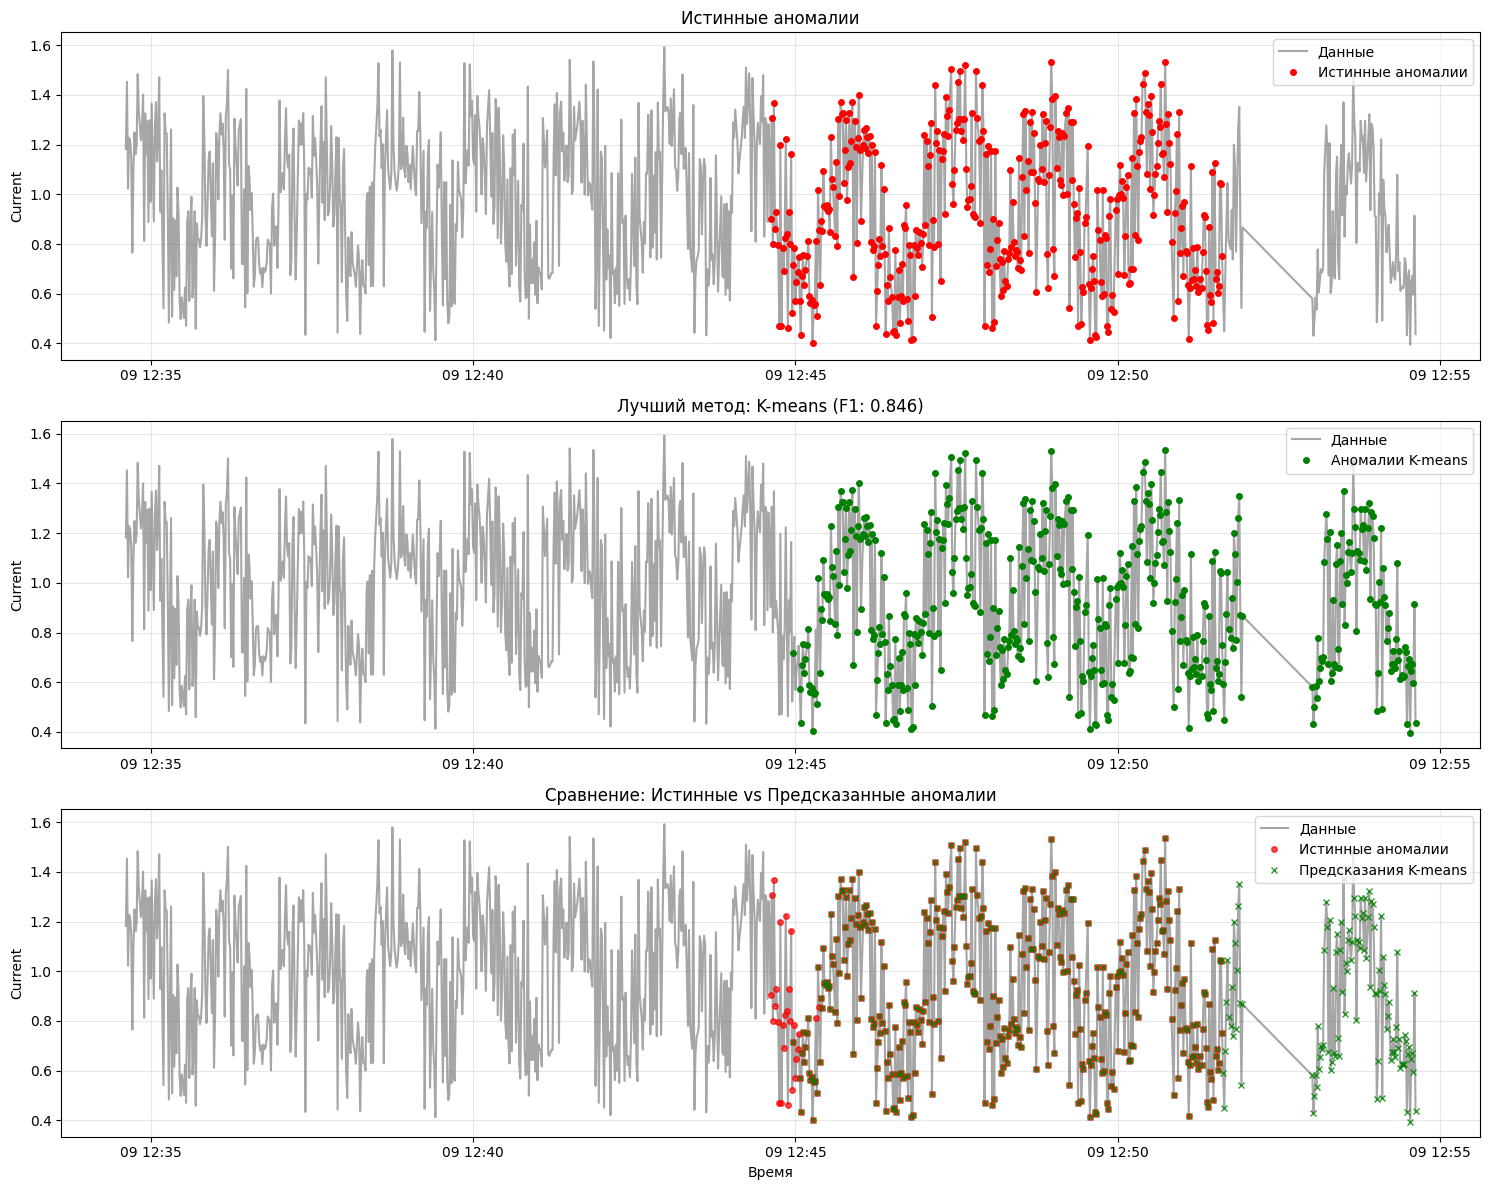

Лучший метод: K-means
F1-Оценка лучшего метода: 0.8456
Всего истинных аномалий: 405.0
Процент истинных аномалий: 37.02%

Рекомендации по использованию методов:
1. Метод квартилей - простой и интерпретируемый, хорош для быстрого анализа
2. K-means - хорошо работает когда аномалии образуют отдельные кластеры
3. DBSCAN - эффективен для обнаружения аномалий как шума в данных
4. Isolation Forest - специализированный алгоритм для обнаружения аномалий


In [23]:
#  Финальная визуализация временных рядов с разными методами
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
time_series_col = 'Current'

# Исходные данные с истинными аномалиями
axes[0].plot(df['datetime'], df[time_series_col], 'gray', alpha=0.7, label='Данные')
anomaly_mask = df['anomaly'] == 1
axes[0].plot(df.loc[anomaly_mask, 'datetime'], df.loc[anomaly_mask, time_series_col],
            'ro', markersize=4, label='Истинные аномалии')
axes[0].set_title('Истинные аномалии')
axes[0].set_ylabel(time_series_col)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Лучший метод по F1-score
best_method = results_comparison.loc[results_comparison['f1'].idxmax()].name
if best_method == 'Метод квартилей 1.5':
    best_anomalies = df_quartile_15['quartile_anomaly_binary']
elif best_method == 'Метод квартилей 3.0':
    best_anomalies = df_quartile_30['quartile_anomaly_binary']
elif best_method == 'K-means':
    best_anomalies = df_fe['kmeans_anomaly']
elif best_method == 'DBSCAN':
    best_anomalies = df_fe['dbscan_anomaly']
else:
    best_anomalies = df_fe['isolation_anomaly']

axes[1].plot(df['datetime'], df[time_series_col], 'gray', alpha=0.7, label='Данные')
best_anomaly_mask = best_anomalies == 1
axes[1].plot(df.loc[best_anomaly_mask, 'datetime'], df.loc[best_anomaly_mask, time_series_col],
            'go', markersize=4, label=f'Аномалии {best_method}')
axes[1].set_title(f'Лучший метод: {best_method} (F1: {results_comparison.loc[best_method, "f1"]:.3f})')
axes[1].set_ylabel(time_series_col)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Сравнение всех методов
axes[2].plot(df['datetime'], df[time_series_col], 'gray', alpha=0.7, label='Данные')

# Истинные аномалии
axes[2].plot(df.loc[anomaly_mask, 'datetime'], df.loc[anomaly_mask, time_series_col],
            'ro', markersize=4, label='Истинные аномалии', alpha=0.7)

# Предсказанные аномалии лучшим методом
axes[2].plot(df.loc[best_anomaly_mask, 'datetime'], df.loc[best_anomaly_mask, time_series_col],
            'gx', markersize=5, label=f'Предсказания {best_method}', alpha=0.8)

axes[2].set_title('Сравнение: Истинные vs Предсказанные аномалии')
axes[2].set_xlabel('Время')
axes[2].set_ylabel(time_series_col)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print(f"Лучший метод: {best_method}")
print(f"F1-Оценка лучшего метода: {results_comparison.loc[best_method, 'f1']:.4f}")
print(f"Всего истинных аномалий: {df['anomaly'].sum()}")
print(f"Процент истинных аномалий: {df['anomaly'].mean()*100:.2f}%")

print("\nРекомендации по использованию методов:")
print("1. Метод квартилей - простой и интерпретируемый, хорош для быстрого анализа")
print("2. K-means - хорошо работает когда аномалии образуют отдельные кластеры")
print("3. DBSCAN - эффективен для обнаружения аномалий как шума в данных")
print("4. Isolation Forest - специализированный алгоритм для обнаружения аномалий")